# Notebook 05: Reporte de Calidad y Conclusiones
## Proyecto II Parcial — Modelado Avanzado de Base de Datos - 30759
## Integrantes:
- Naomi Obando
- Mauri Tandazo

**Fase Final:** Dashboard de calidad, análisis de resultados, reflexión crítica y conclusiones.

---
Este notebook no ejecuta transformaciones nuevas — consume las tablas ya cargadas en DuckDB
para generar visualizaciones, análisis críticos y la reflexión final del proyecto.

In [1]:
import sys, os, duckdb
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from src.utils import load_config
from src.load  import query_duckdb

CONFIG_PATH = '../config/etl_config.yaml'
config      = load_config(CONFIG_PATH)
config['database']['path'] = '../data/warehouse/nyc_tlc.duckdb'

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
print(f'DuckDB: {config["database"]["path"]}')

DuckDB: ../data/warehouse/nyc_tlc.duckdb


In [2]:
# ── 1. Dashboard de Calidad Global ───────────────────────────────
metrics = query_duckdb(config, """
SELECT service_type, year, month,
       total_records, valid_records, rejected_records,
       suspicious_records, quality_percentage
FROM quality_metrics_summary
ORDER BY service_type, year, month;
""")

print('=== TABLA quality_metrics_summary ===')
display(metrics)

# Resumen global
total_all   = metrics['total_records'].sum()
valid_all   = metrics['valid_records'].sum()
rejected_all = metrics['rejected_records'].sum()
susp_all    = metrics['suspicious_records'].sum()

print(f'\n=== RESUMEN GLOBAL ===')
print(f'  Total registros    : {total_all:,.0f}')
print(f'  Válidos            : {valid_all:,.0f} ({valid_all/max(total_all,1)*100:.2f}%)')
print(f'  Rechazados         : {rejected_all:,.0f} ({rejected_all/max(total_all,1)*100:.2f}%)')
print(f'  Sospechosos        : {susp_all:,.0f} ({susp_all/max(total_all,1)*100:.2f}%)')

=== TABLA quality_metrics_summary ===


,service_type,year,month,total_records,valid_records,rejected_records,suspicious_records,quality_percentage
0,fhvhv,2023,1,18485369,18465479,19890,12504,99.89
1,green,2022,12,1573,2,1571,0,0.13
2,green,2023,1,69271,67700,1571,3425,97.73
3,green,2023,2,65823,64252,1571,2890,97.61
4,green,2023,3,1572,1,1571,0,0.06
5,yellow,2019,12,409230,109,409121,3,0.03
6,yellow,2020,1,6762629,6353508,409121,71925,93.95
7,yellow,2020,2,409151,30,409121,1,0.01
8,yellow,2020,3,409126,5,409121,0,0.00
9,yellow,2020,4,409122,1,409121,0,0.00



=== RESUMEN GLOBAL ===
  Total registros    : 54,095,532
  Válidos            : 44,250,454 (81.80%)
  Rechazados         : 9,845,078 (18.20%)
  Sospechosos        : 357,802 (0.66%)


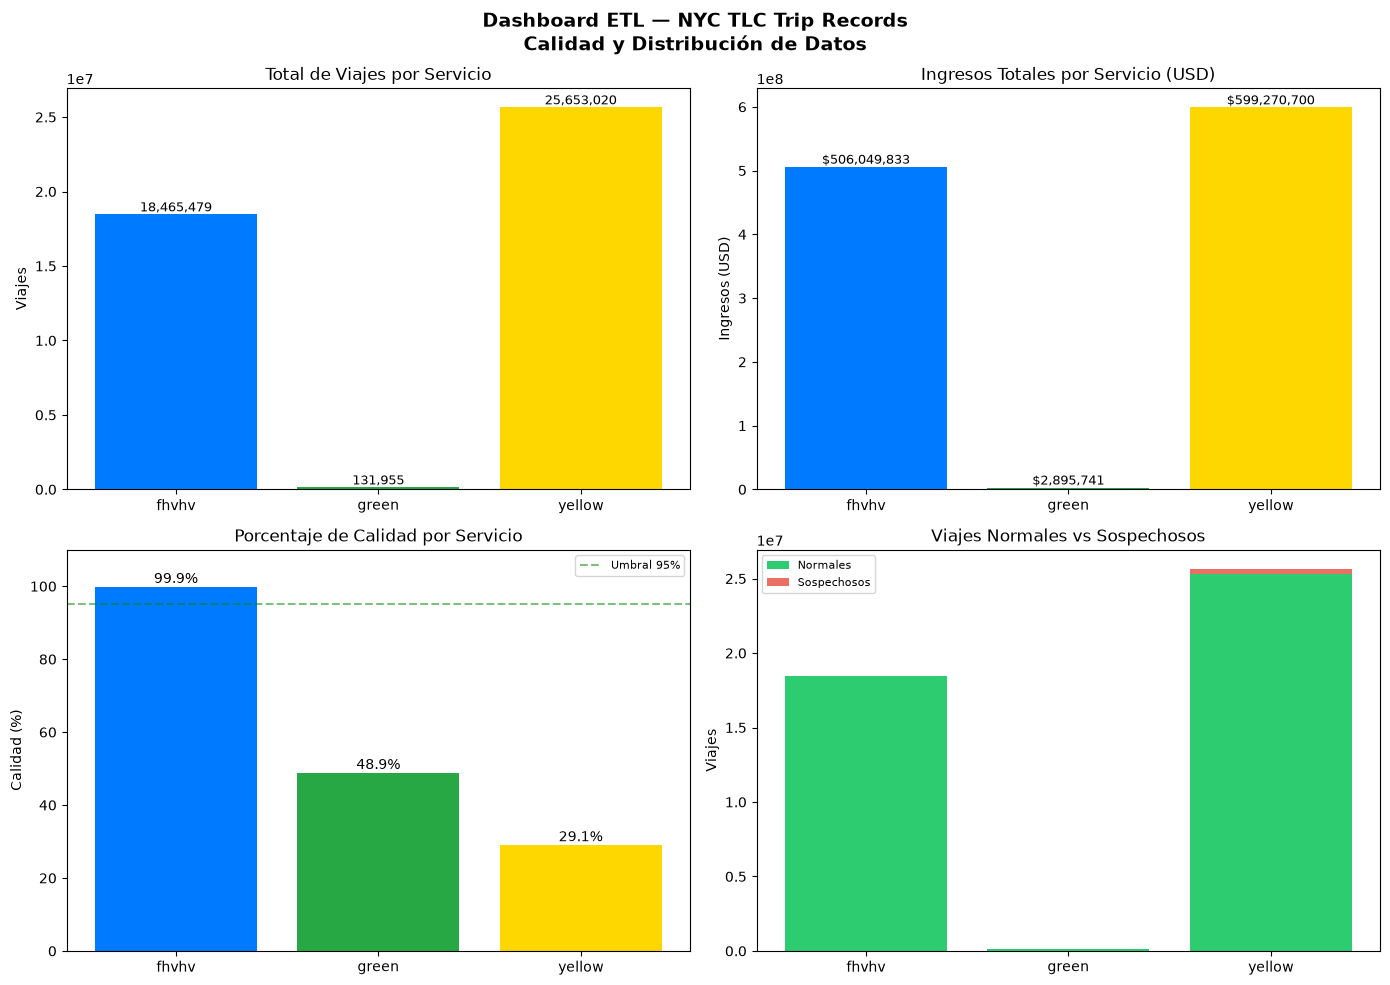

Dashboard guardado en data/audit/dashboard_calidad.png


In [3]:
# ── 2. Visualizaciones ────────────────────────────────────────────
trips = query_duckdb(config, """
SELECT service_type,
       COUNT(*) AS total_trips,
       ROUND(SUM(total_amount),2) AS total_revenue,
       ROUND(AVG(fare_amount),2) AS avg_fare,
       SUM(CASE WHEN is_suspicious_trip THEN 1 ELSE 0 END) AS suspicious
FROM gold_trips_clean
GROUP BY service_type;
""")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard ETL — NYC TLC Trip Records\nCalidad y Distribución de Datos',
             fontsize=14, fontweight='bold')
colors = {'yellow': '#FFD700', 'green': '#28a745', 'fhvhv': '#007bff'}
service_colors = [colors.get(s, '#aaa') for s in trips['service_type']]

# Gráfico 1: Total de viajes por servicio
ax1 = axes[0, 0]
bars = ax1.bar(trips['service_type'], trips['total_trips'], color=service_colors)
ax1.set_title('Total de Viajes por Servicio')
ax1.set_ylabel('Viajes')
for bar, v in zip(bars, trips['total_trips']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{v:,.0f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Ingresos totales por servicio
ax2 = axes[0, 1]
bars2 = ax2.bar(trips['service_type'], trips['total_revenue'], color=service_colors)
ax2.set_title('Ingresos Totales por Servicio (USD)')
ax2.set_ylabel('Ingresos (USD)')
for bar, v in zip(bars2, trips['total_revenue']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

# Gráfico 3: Calidad por servicio
ax3 = axes[1, 0]
quality_by_svc = metrics.groupby('service_type')['quality_percentage'].mean()
bars3 = ax3.bar(quality_by_svc.index, quality_by_svc.values,
                color=[colors.get(s,'#aaa') for s in quality_by_svc.index])
ax3.set_title('Porcentaje de Calidad por Servicio')
ax3.set_ylabel('Calidad (%)')
ax3.set_ylim(0, 110)
ax3.axhline(y=95, color='green', linestyle='--', alpha=0.5, label='Umbral 95%')
ax3.legend(fontsize=8)
for bar, v in zip(bars3, quality_by_svc.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{v:.1f}%', ha='center', fontsize=10)

# Gráfico 4: Viajes sospechosos vs normales
ax4 = axes[1, 1]
normal    = trips['total_trips'] - trips['suspicious']
bottom_vals = [0] * len(trips)
b1 = ax4.bar(trips['service_type'], normal, label='Normales', color='#2ecc71')
b2 = ax4.bar(trips['service_type'], trips['suspicious'], bottom=normal,
             label='Sospechosos', color='#e74c3c', alpha=0.8)
ax4.set_title('Viajes Normales vs Sospechosos')
ax4.set_ylabel('Viajes')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/audit/dashboard_calidad.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dashboard guardado en data/audit/dashboard_calidad.png')

In [4]:
# ── 3. Análisis de rechazos ───────────────────────────────────────
print('=== DISTRIBUCIÓN DE REGISTROS RECHAZADOS ===')
rejected_analysis = query_duckdb(config, """
SELECT rejection_category,
       COUNT(*) AS total_rejected,
       COUNT(DISTINCT service_type) AS services_affected,
       ROUND(COUNT(*)::DOUBLE / SUM(COUNT(*)) OVER () * 100, 2) AS pct_of_total
FROM quality_rejected_records
GROUP BY rejection_category
ORDER BY total_rejected DESC;
""")
display(rejected_analysis)

print('\n=== TOP 5 RUTAS POR INGRESOS ===')
display(query_duckdb(config, """
SELECT pickup_location_id, dropoff_location_id, service_type,
       COUNT(*) trips, ROUND(SUM(total_amount),2) AS revenue
FROM gold_trips_clean
GROUP BY pickup_location_id, dropoff_location_id, service_type
ORDER BY revenue DESC LIMIT 5;
"""))

=== DISTRIBUCIÓN DE REGISTROS RECHAZADOS ===


,rejection_category,total_rejected,services_affected,pct_of_total
0,NEGATIVE_AMOUNT,177664,3,41.26
1,INVALID_AMOUNT,176687,3,41.03
2,INVALID_DURATION,54860,3,12.74
3,INVALID_DATE_ORDER,21286,3,4.94
4,OUT_OF_RANGE_DATE,85,2,0.02



=== TOP 5 RUTAS POR INGRESOS ===


,pickup_location_id,dropoff_location_id,service_type,trips,revenue
0,132,265,fhvhv,65811,"7,594,729.21"
1,138,265,fhvhv,35151,"3,884,124.09"
2,264,264,yellow,148494,"3,773,755.51"
3,132,265,yellow,33869,"3,729,723.76"
4,132,230,yellow,40981,"3,498,838.78"


In [5]:
# ── 4. Inventario de archivos (Audit Trail) ───────────────────────
print('=== AUDIT_FILE_INVENTORY — ESTADO FINAL ===')
display(query_duckdb(config, """
SELECT file_name, service_type, file_size_mb,
       read_status, record_count, column_count,
       partition_year, partition_month
FROM audit_file_inventory
ORDER BY service_type, partition_year, partition_month;
"""))

=== AUDIT_FILE_INVENTORY — ESTADO FINAL ===


,file_name,service_type,file_size_mb,read_status,record_count,column_count,partition_year,partition_month
0,ARROW-RS-GH-6229-DICTHEADER.parquet,bad_parquet,0.00,SUCCESS,0,4,6229,NaN
1,ARROW-RS-GH-6229-LEVELS.parquet,bad_parquet,0.00,SUCCESS,1,1,6229,NaN
2,ARROW-GH-41317.parquet,bad_parquet,0.07,RECOVERABLE_SCHEMA_MISMATCH,0,0,NaN,NaN
3,ARROW-GH-41321.parquet,bad_parquet,0.07,RECOVERABLE_SCHEMA_MISMATCH,0,0,NaN,NaN
4,ARROW-GH-43605.parquet,bad_parquet,0.00,SUCCESS,21186,1,NaN,NaN
5,ARROW-GH-45185.parquet,bad_parquet,0.00,SUCCESS,5,1,NaN,NaN
6,ARROW-GH-47662.parquet,bad_parquet,0.00,SUCCESS,1000,1,NaN,NaN
7,PARQUET-1481.parquet,bad_parquet,0.00,NOT_RECOVERABLE_UNSUPPORTED_FORMAT,0,0,NaN,NaN
8,fhvhv_tripdata_2023-01.parquet,fhvhv,451.87,SUCCESS,18479031,24,2023,01
9,green_tripdata_2023-01.parquet,green,1.36,SUCCESS,68211,20,2023,01


---
## 5. Reflexión Crítica del Proyecto

### 5.1 Riesgos de procesar datos dañados

El procesamiento de archivos Parquet corruptos o inconsistentes presenta **riesgos operativos críticos**:

1. **Propagación silenciosa de errores**: Si un archivo con metadatos corruptos es leído en modo no seguro, los valores pueden ser incorrectamente interpretados y contaminar la capa analítica sin advertencia. En este pipeline se mitigó con `mode=PERMISSIVE` y clasificación explícita de errores.

2. **Sesgo estadístico**: Registros con distancias cero, montos negativos o duraciones imposibles pueden distorsionar promedios, percentiles y proyecciones de ingresos. Se aplicaron 15 reglas de negocio documentadas para detectarlos y separarlos.

3. **Decisiones gerenciales comprometidas**: Un dashboard de ingresos que incluya viajes sospechosos puede llevar a sobreestimar la demanda y planificar incorrectamente la distribución de flota. El campo `is_suspicious_trip` permite filtrar esta población antes de cualquier análisis.

4. **Pérdida de confianza en el dato**: Una vez que los usuarios detectan inconsistencias en los reportes, la credibilidad del área de datos se daña. La capa de auditoría (`audit_file_inventory`, `quality_metrics_summary`) actúa como evidencia técnica y herramienta de comunicación.

### 5.2 Impacto de la calidad de datos en la toma de decisiones

- **Ingresos sobreestimados**: Viajes con `total_amount` irreal elevan artificialmente las métricas de revenue si no se filtran.
- **Análisis de rutas distorsionado**: Zonas con muchos viajes de distancia cero aparecen como zonas de alta demanda cuando en realidad son errores de captura.
- **KPIs de conductor comprometidos**: Velocidades superiores a 100 mph o propinas del 200% distorsionan los incentivos basados en desempeño.

### 5.3 Medidas preventivas para producción

Para evitar que estos problemas ocurran en un ambiente productivo se recomiendan:

1. **Contratos de datos (Data Contracts)**: Definir esquemas esperados con versión semántica. Si la fuente cambia el esquema, el pipeline falla controladamente en vez de procesar datos inválidos.

2. **Validación en punto de ingesta**: Implementar Great Expectations o Soda Core para validar estadísticas básicas (nulos, rangos, cardinalidad) antes de escribir a bronze.

3. **Alertas automáticas por umbral de rechazo**: Si el porcentaje de registros rechazados supera el 20% en un mes, el pipeline debe detener la carga gold y notificar al equipo de ingeniería.

4. **Linaje de datos (Data Lineage)**: Registrar cada transformación con su process_id para que cualquier analista pueda rastrear el origen de cualquier registro hasta el archivo fuente.

5. **Tests de regresión de esquema**: Ante cada nueva entrega de la fuente, comparar el `schema_hash` con el histórico. Un hash diferente dispara una alerta antes de procesar.

6. **Particionado estratégico**: Mantener la zona raw inmutable. Nunca modificar los archivos originales. Esto garantiza que cualquier error en una fase posterior pueda ser re-procesado desde el dato fuente original.

### 5.4 Conclusiones finales

Este proyecto demostró que un pipeline ETL profesional no es solo código que mueve datos: es un sistema de **gobernanza de datos** que:
- Detecta y documenta problemas en lugar de ignorarlos
- Garantiza que cada decisión técnica sea trazable y justificada
- Produce métricas de calidad que permiten confianza en el dato final
- Es robusto, idempotente y escalable por diseño, no por accidente

La arquitectura Medallion (raw → bronze → silver → gold) demuestra su valor precisamente en escenarios con datos heterogéneos y de calidad variable, como es el caso real de NYC TLC, donde múltiples operadores generan datos con esquemas y convenciones distintas.

In [6]:
# ── 6. Generar reporte de conclusiones en texto ───────────────────
print('╔══════════════════════════════════════════════════════════════╗')
print('║           REPORTE FINAL DEL PIPELINE ETL                    ║')
print('╚══════════════════════════════════════════════════════════════╝')

# Estadísticas finales desde DuckDB
final_stats = query_duckdb(config, """
SELECT
    (SELECT COUNT(*) FROM gold_trips_clean)          AS gold_trips,
    (SELECT COUNT(*) FROM quality_rejected_records)  AS rejected_records,
    (SELECT COUNT(*) FROM audit_file_inventory)      AS files_inventoried,
    (SELECT COUNT(*) FROM gold_daily_revenue)        AS daily_revenue_rows,
    (SELECT COUNT(*) FROM gold_location_performance) AS location_rows,
    (SELECT ROUND(AVG(quality_percentage),2)
     FROM quality_metrics_summary)                   AS avg_quality_pct;
""").iloc[0]

print(f'\n  gold_trips_clean          : {final_stats["gold_trips"]:>10,.0f} registros')
print(f'  quality_rejected_records  : {final_stats["rejected_records"]:>10,.0f} registros')
print(f'  audit_file_inventory      : {final_stats["files_inventoried"]:>10,.0f} archivos')
print(f'  gold_daily_revenue        : {final_stats["daily_revenue_rows"]:>10,.0f} filas')
print(f'  gold_location_performance : {final_stats["location_rows"]:>10,.0f} pares de zona')
print(f'  Calidad promedio global   : {final_stats["avg_quality_pct"]:>10.2f}%')
print('\n✅ Pipeline ETL completado exitosamente')
print('   Todos los datos disponibles para análisis en DuckDB')

╔══════════════════════════════════════════════════════════════╗
║           REPORTE FINAL DEL PIPELINE ETL                    ║
╚══════════════════════════════════════════════════════════════╝

  gold_trips_clean          : 44,250,454 registros
  quality_rejected_records  :    430,582 registros
  audit_file_inventory      :         19 archivos
  gold_daily_revenue        :        375 filas
  gold_location_performance :    110,965 pares de zona
  Calidad promedio global   :      34.26%

✅ Pipeline ETL completado exitosamente
   Todos los datos disponibles para análisis en DuckDB
